### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Datasets


In [2]:
# primary dataset
file_path = 'gs://data-analyst-wage-trends/prim/gsearch_jobs.csv'
data_jobs = pd.read_csv(file_path, encoding='latin-1')

# supplementary dataset
file_path2 = 'gs://data-analyst-wage-trends/suppl-1/cost_of_living_us.csv'
cost_living = pd.read_csv(file_path2, encoding='latin-1')

In [3]:
# selecting columns
data_jobs = data_jobs[['title', 'company_name', 'location', 'salary_hourly', 'salary_yearly', 'schedule_type', 'work_from_home', 'date_time', 'description_tokens']]

# rename column
data_jobs.rename(columns={'description_tokens': 'skillset'}, inplace=True)
data_jobs

,title,company_name,location,salary_hourly,salary_yearly,schedule_type,work_from_home,date_time,skillset
0,Data Analyst,Meta,Anywhere,NaN,122000.0,Full-time,True,2023-08-04 03:00:13.797776,"['tableau', 'r', 'python', 'sql']"
1,Data Analyst,ATC,United States,NaN,NaN,Full-time,NaN,2023-08-04 03:00:13.797776,[]
2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",NaN,NaN,Full-time,NaN,2023-08-04 03:00:13.797776,['sql']
3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,20.0,NaN,Contractor,True,2023-08-04 03:00:13.797776,"['powerpoint', 'excel', 'power_bi']"
4,Data Analyst | Workforce Management,Krispy Kreme,United States,NaN,100000.0,Contractor,NaN,2023-08-04 03:00:13.797776,"['powerpoint', 'excel', 'outlook', 'word']"
...,...,...,...,...,...,...,...,...,...
61948,Marketing Data & BI Analyst II,EDWARD JONES,"Houstonia, MO",NaN,103781.0,Full-time,NaN,2022-11-04 03:40:23.706734,"['power_bi', 'tableau', 'excel', 'snowflake', ..."
61949,Lead-Data Analyst,EDWARD JONES,"Marshfield, MO",NaN,144481.5,Full-time,NaN,2022-11-24 04:00:08.710801,[]
61950,Lead-Data Analyst,EDWARD JONES,"High Point, MO",NaN,144481.5,Full-time,NaN,2022-12-07 04:00:12.563831,[]
61951,Lead-Data Analyst,EDWARD JONES,"Calhoun, MO",NaN,144481.5,Full-time,NaN,2022-12-08 04:00:15.975728,[]


In [4]:
# selecting columns
cost_living = cost_living[['state','total_cost','family_member_count','areaname']]
cost_living

,state,total_cost,family_member_count,areaname
0,AL,39254.0532,1p0c,"Montgomery, AL MSA"
1,AL,57194.3256,1p1c,"Montgomery, AL MSA"
2,AL,76141.0308,1p2c,"Montgomery, AL MSA"
3,AL,94203.5328,1p3c,"Montgomery, AL MSA"
4,AL,100823.5200,1p4c,"Montgomery, AL MSA"
...,...,...,...,...
31425,WY,55415.4672,2p0c,"Weston County, WY"
31426,WY,75424.1832,2p1c,"Weston County, WY"
31427,WY,96413.1684,2p2c,"Weston County, WY"
31428,WY,113294.2260,2p3c,"Weston County, WY"


### Discover Schema

In [5]:
# primary dataset
data_jobs.columns

Index(['title', 'company_name', 'location', 'salary_hourly', 'salary_yearly',
       'schedule_type', 'work_from_home', 'date_time', 'skillset'],
      dtype='object')

In [6]:
data_jobs.dtypes

,0
title,object
company_name,object
location,object
salary_hourly,float64
salary_yearly,float64
schedule_type,object
work_from_home,object
date_time,object
skillset,object


In [7]:
data_jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61953 entries, 0 to 61952
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           61953 non-null  object 
 1   company_name    61953 non-null  object 
 2   location        61916 non-null  object 
 3   salary_hourly   5900 non-null   float64
 4   salary_yearly   4069 non-null   float64
 5   schedule_type   61707 non-null  object 
 6   work_from_home  27980 non-null  object 
 7   date_time       61953 non-null  object 
 8   skillset        61953 non-null  object 
dtypes: float64(2), object(7)
memory usage: 4.3+ MB


In [8]:
data_jobs.index

RangeIndex(start=0, stop=61953, step=1)

In [9]:
# secondary dataset
cost_living.columns

Index(['state', 'total_cost', 'family_member_count', 'areaname'], dtype='object')

In [10]:
cost_living.dtypes

,0
state,object
total_cost,float64
family_member_count,object
areaname,object


In [11]:
cost_living.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31430 entries, 0 to 31429
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   state                31430 non-null  object 
 1   total_cost           31430 non-null  float64
 2   family_member_count  31430 non-null  object 
 3   areaname             31430 non-null  object 
dtypes: float64(1), object(3)
memory usage: 982.3+ KB


In [12]:
cost_living.index

RangeIndex(start=0, stop=31430, step=1)

### Display Sample

In [13]:
data_jobs.sample(5)

,title,company_name,location,salary_hourly,salary_yearly,schedule_type,work_from_home,date_time,skillset
649,Seeking Python/Data Analysis Beginners AND Exp...,Upwork,Anywhere,NaN,NaN,Contractor,True,2023-08-26 03:00:13.992064,['python']
53457,Active Acoustic Data Analysis Support (Level II),IBSS,United States,NaN,NaN,Full-time,NaN,2022-12-07 04:00:12.563831,"['python', 'perl']"
25644,Data Analyst,Shook Hardy Bacon Llp,"Kansas City, MO",NaN,NaN,Full-time,NaN,2023-07-23 03:00:11.801859,[]
30166,Business Intelligence Analyst,State of Colorado,"Pueblo, CO",NaN,NaN,Full-time,NaN,2025-02-13 04:00:20.099300,[]
58156,"Sr. Data Analyst, Pricing & Packaging","AppFolio, Inc.",Anywhere,NaN,NaN,Full-time,True,2022-12-11 04:00:10.225147,"['github', 'tableau', 'excel', 'sql', 'r', 'py..."


In [14]:
cost_living.sample(5)

,state,total_cost,family_member_count,areaname
12197,MA,92204.4960,2p2c,"Providence-Fall River, RI-MA HUD Metro FMR Are..."
24383,TN,67153.4532,1p3c,"Johnson City, TN MSA"
16335,MT,52394.0976,2p0c,"Petroleum County, MT"
100,AL,37130.2032,1p0c,"Chilton County, AL HUD Metro FMR Area"
23746,SD,65391.1992,2p1c,"Clark County, SD"


### Summarize Central Tendency

In [27]:
data_jobs.describe(include = "all")

,title,company_name,location,salary_hourly,salary_yearly,schedule_type,work_from_home,date_time,skillset
count,61953,61953,61916,5900.000000,4069.000000,61707,61953,61953,61953
unique,23292,13429,1254,NaN,NaN,32,2,6588,11276
top,Data Analyst,Upwork,Anywhere,NaN,NaN,Full-time,False,2023-01-30 04:00:45.438868,[]
freq,6444,7533,18067,NaN,NaN,45082,33973,10,13352
mean,NaN,NaN,NaN,40.539588,104115.406718,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,22.214540,36024.388492,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,7.250000,29289.840000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,23.265000,80000.180000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,33.500000,96500.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,55.000000,120000.000000,NaN,NaN,NaN,NaN


In [28]:
cost_living.describe(include = "all")

,state,total_cost,family_member_count,areaname
count,31430,31430.000000,31430,31430
unique,51,NaN,10,2561
top,TX,NaN,1p0c,"Atlanta-Sandy Springs-Roswell, GA HUD Metro FM..."
freq,2540,NaN,3143,240
mean,NaN,70901.683601,NaN,NaN
std,NaN,21846.545235,NaN,NaN
min,NaN,30087.662400,NaN,NaN
25%,NaN,53776.019400,NaN,NaN
50%,NaN,70977.682800,NaN,NaN
75%,NaN,85371.341100,NaN,NaN


### Plots of Important Features

In [17]:
# fill NA values with False for work_from_home
data_jobs['work_from_home'] = data_jobs['work_from_home'].fillna(False)

/tmp/ipython-input-2316490098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_jobs['work_from_home'] = data_jobs['work_from_home'].fillna(False)


<Axes: xlabel='work_from_home', ylabel='count'>

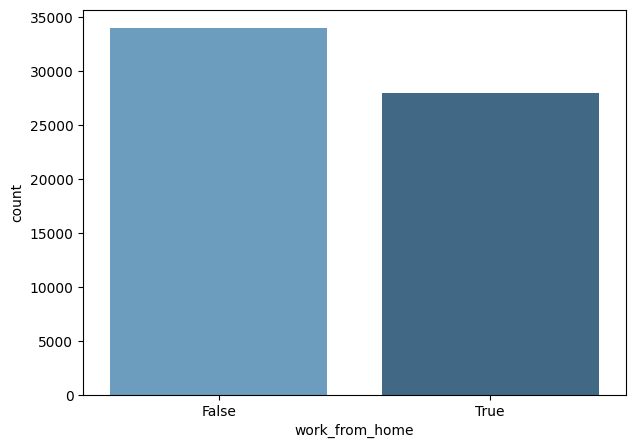

In [18]:
plt.figure(figsize=(7, 5))
sns.countplot(x='work_from_home', data=data_jobs,
              palette='Blues_d',
              hue='work_from_home',
              legend=False,
              order=data_jobs['work_from_home'].value_counts().index)

<Axes: xlabel='count', ylabel='schedule_type'>

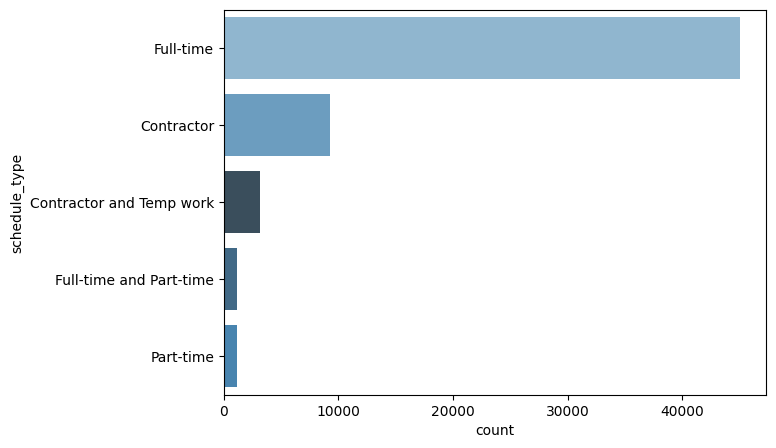

In [25]:
top_5_categories = data_jobs['schedule_type'].value_counts().head(5).index

# 2. Plot only those top 5
plt.figure(figsize=(7, 5))
sns.countplot(
    y='schedule_type',
    data=data_jobs[data_jobs['schedule_type'].isin(top_5_categories)],
    palette='Blues_d',
    hue='schedule_type',
    legend=False,
    order=top_5_categories  # This restricts and sorts the bars to just the top 5
)

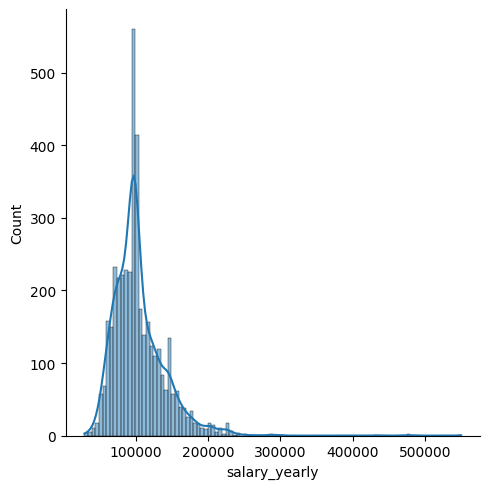

In [19]:
sns.displot(data_jobs["salary_yearly"],kde = True)

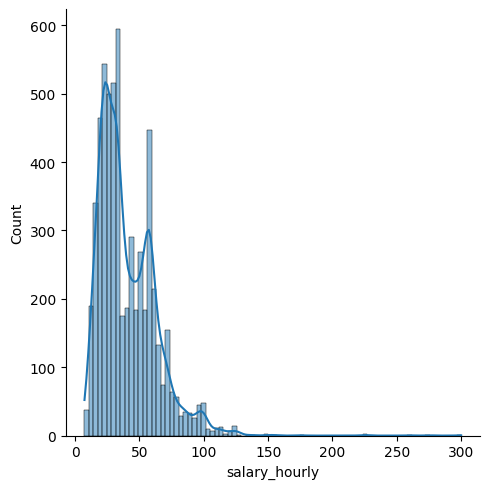

In [20]:
sns.displot(data_jobs["salary_hourly"],kde = True)

/tmp/ipython-input-162855818.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


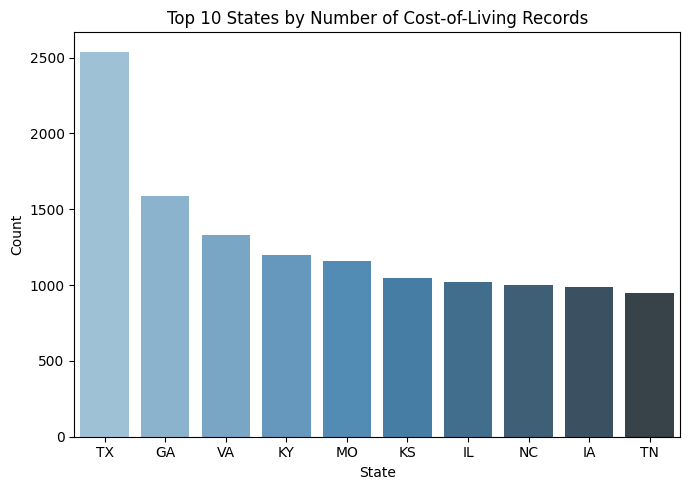

In [22]:
# plot the top 10 states by cost of living records
top_states = cost_living['state'].value_counts().head(10).index

plt.figure(figsize=(7, 5))
sns.countplot(
    x='state',
    data=cost_living[cost_living['state'].isin(top_states)],
    order=top_states,
    palette='Blues_d'
)
plt.title('Top 10 States by Number of Cost-of-Living Records')
plt.xlabel('State')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


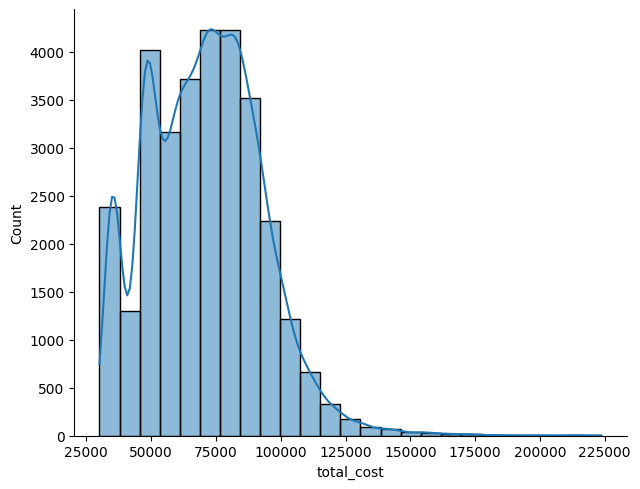

In [23]:
sns.displot(
    cost_living["total_cost"],
    bins=25,
    kde=True,
    height=5,
    aspect=1.3
)
plt.show()


#### Observations

##### Data Analyst Jobs Dataset \(primary)

**schedule_type**
*   Most of Data Analyst postings are full-time, with contractor roles representing a smaller share.
*   Part-time/mixed schedule types appear rarely, suggesting that Data Analyst positions are primarily full-time roles.

**work_from_home**
*   Most postings are classified as non-remote, potentially suggesting that on-site roles dominate the market during these years.

**salary_hourly**
*   Hourly wages are slightly right-skewed, concentrated between approximately \$23 and \$55 per hour, with a median of $33.50.
*   Some rare, extremely high hourly rates exist, likely reflect specialized/short-term contract roles.

**salary_yearly**
*   Annual salaries are right-skewed, with most postings clustered between \$80,000 and \$120,000, and a median of $96,500.
*   Few high-paying outliers raise the mean and extend the upper tail of the distribution.



##### Cost of Living Dataset \(secondary)

**total_cost**
*   The distribution of total annual cost of living is right-skewed, with most observations concentrated between about \$54,000 and \$85,000, and a median of $70,978.
*   Few high-cost areas extend the upper tail, indicating substantial geographic variation in living expenses.

**state**
*   Distribution of cost-of-living records is uneven across states, with Texas contributing the largest number of observations.

